<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
x = data.data
y = data.target

x_train, x_test, y_train, y_test = train_test_split (
    x,
    y,
    test_size=0.3,
    random_state=42
)

print("x treino: ", len(x_train))
print("x test: ", len(x_test))
print("y treino: ", len(y_train))
print("y test: ", len(y_test))

x treino:  105
x test:  45
y treino:  105
y test:  45


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

modelo = DecisionTreeClassifier()
modelo.fit(x_train, y_train)

y_pred_train = modelo.predict(x_train)
y_pred_test = modelo.predict(x_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print("Acurácia no treino:", acc_train)
print("Acurácia no teste:", acc_test)

Acurácia no treino: 1.0
Acurácia no teste: 1.0


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

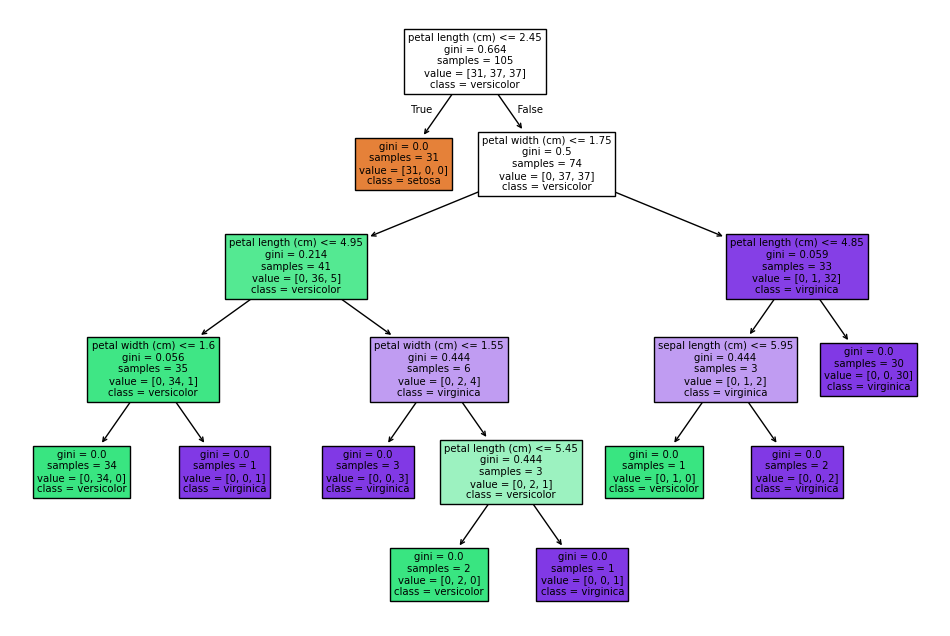

In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))

plot_tree(
    modelo,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True
)

plt.show()

**Adicione seu texto de solução aqui**.

- O atributo que aparece na raiz é petal lenght (cm) - comprimento de pétala
- A profundidade da árvore é 5

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [ ]:
import pandas as pd

resultados = []

profundidades = [1,2,3,4,5,6,7,8,9,None]

for d in profundidades:
    
    modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
    modelo.fit(x_train, y_train)

    y_pred_train = modelo.predict(x_train)
    y_pred_test = modelo.predict(x_test)
    
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    profundidade_real = modelo.get_depth()
    folhas = modelo.get_n_leaves()

    resultados.append([
        d,
        acc_train,
        acc_test,
        profundidade_real,
        folhas
    ])

tabela = pd.DataFrame(
    resultados,
    columns=[
        "max_depth",
        "acuracia_treino",
        "acuracia_teste",
        "profundidade_arvore",
        "numero_folhas"
    ]
)

print(tabela)

   max_depth  acuracia_treino  acuracia_teste  profundidade_arvore  \
0        1.0         0.647619        0.711111                    1   
1        2.0         0.942857        0.977778                    2   
2        3.0         0.952381        1.000000                    3   
3        4.0         0.971429        1.000000                    4   
4        5.0         0.990476        1.000000                    5   
5        6.0         1.000000        1.000000                    6   
6        7.0         1.000000        1.000000                    6   
7        8.0         1.000000        1.000000                    6   
8        9.0         1.000000        1.000000                    6   
9        NaN         1.000000        1.000000                    6   

   numero_folhas  
0              2  
1              3  
2              5  
3              7  
4              9  
5             10  
6             10  
7             10  
8             10  
9             10  


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

Resposta:
- A profundidade que começa o overfitting é da 6 em diante, visto que a repetição é vista após a profundidade 5
- Quando não se atribui uma profundidade haverá uma ajuste extremo, fazendo com que se cheguem a nós puros. Por não se ter limite ocorre um overfitting trazendo uma acurácia 1

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [7]:
criterios = ["gini", "entropy"]

for c in criterios:

    modelo = DecisionTreeClassifier(criterion=c, random_state=42)
    modelo.fit(x_train, y_train)
    folhas = modelo.get_n_leaves()

    y_pred_test = modelo.predict(x_test)

    acc = accuracy_score(y_test, y_pred_test)
    profundidade = modelo.get_depth()

    print("Criterion:", c)
    print("Profundidade:", profundidade)
    print("Acurácia:", acc)
    print("Número folhas:", folhas)
    print("-------------------")

Criterion: gini
Profundidade: 6
Acurácia: 1.0
Número folhas: 10
-------------------
Criterion: entropy
Profundidade: 7
Acurácia: 0.9777777777777777
Número folhas: 10
-------------------


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [8]:
melhor_acuracia = 0
melhor_parametro = None

print("min_samples_leaf | acc_treino | acc_teste")

for leaf in range(1, 11):

    modelo = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    modelo.fit(x_train, y_train)

    y_pred_train = modelo.predict(x_train)
    y_pred_test = modelo.predict(x_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    print(leaf, "|", round(acc_train,3), "|", round(acc_test,3))

    if acc_test > melhor_acuracia:
        melhor_acuracia = acc_test
        melhor_parametro = leaf

print("\nMelhor modelo encontrado:")
print("min_samples_leaf =", melhor_parametro)
print("acurácia no teste =", melhor_acuracia)

min_samples_leaf | acc_treino | acc_teste
1 | 1.0 | 1.0
2 | 0.971 | 1.0
3 | 0.962 | 1.0
4 | 0.962 | 1.0
5 | 0.943 | 1.0
6 | 0.943 | 1.0
7 | 0.943 | 1.0
8 | 0.943 | 1.0
9 | 0.943 | 0.978
10 | 0.943 | 0.978

Melhor modelo encontrado:
min_samples_leaf = 1
acurácia no teste = 1.0


Foi investigado o hiperparâmetro min_samples_leaf, que controla o número mínimo de amostras em cada folha da árvore de decisão. Observou-se que valores pequenos produzem árvores mais complexas e com maior acurácia no conjunto de treino. À medida que o valor aumenta, a árvore se torna mais simples e a acurácia tende a diminuir. O melhor modelo encontrado utilizou min_samples_leaf = 1, alcançando aproximadamente 97% de acurácia no conjunto de teste.